# Validation and Model Selection - Fed-Batch Bioreactor

A hybrid model that fits its training data is not necessarily a good model: a large enough network can memorise measurement noise. The way to tell the difference, and to choose how big the network should be, is to measure performance on data the model never saw during training.

This notebook uses the fed-batch bioreactor from [Importing Measured Data](fedbatch_example.ipynb) and a **leave-one-batch-out** protocol:

1. Train the hybrid model on a subset of the logged batches.
2. Predict the held-out batch from its initial charge with `model.predict()`, and score the prediction against that batch's measurements.
3. Sweep the network width and read off the size that generalises best.

Because the held-out batch never enters the fit, its error is an honest estimate of how the model will do on a new run.

Imports, including `HybridDAE` for the fit/predict pipeline.

In [1]:
import logging

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.solvers import SolverConfig
from sindae import HybridDAE

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.WARNING, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Problem and data

The problem definition is the standard fed-batch model (all four states observed), identical to the first fed-batch example.

In [2]:
class FedBatchBioreactorProblem(ProblemDefinition):
    def __init__(self, 
                 params, 
                 ics, 
                 input_dim, 
                 z_dim, 
                 t_span, 
                 nfe, 
                 ncp,
                 obs_times=None, 
                 obs_values=None, 
                 obs_dim=None):
        
        super().__init__(ics, input_dim, z_dim, t_span, nfe, ncp,
                         obs_times, obs_values, obs_dim)
        
        self.params = params

    def build_trajectory(self, block, traj_idx):
        p  = self.params
        t0 = self.t_span[0]
        x0 = self.ics[traj_idx]
        Sf = float(x0[2])

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.x    = pyo.Var(block.t, range(self.input_dim),
                             domain=pyo.NonNegativeReals, initialize=1.0)
        block.z    = pyo.Var(block.t, range(self.z_dim), initialize=0.1)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        Feed, Ypx, Yxs = p['Feed'], p['Ypx'], p['Yxs']

        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            mu = b.z[t, 0]
            X, P, S, V = b.x[t, 0], b.x[t, 1], b.x[t, 2], b.x[t, 3]
            if s == 0:
                return b.dxdt[t, 0] == mu * X - Feed * (X / V)
            elif s == 1:
                return b.dxdt[t, 1] == Ypx * mu * X - Feed * (P / X)
            elif s == 2:
                return b.dxdt[t, 2] == Feed * (Sf - S) / V - mu * (X / Yxs)
            else:
                return b.dxdt[t, 3] == Feed

        for j in range(self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

    def get_input_vars(self, block, t):
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

In [3]:
FB_PARAMS = {
    'Feed':     0.05, 
    'Ypx':      0.2, 
    'Yxs':      0.5, 
    'Ks':       1.0,  # true Monod constants (final check only)
    'mu_max':   0.2,  # true Monod constants (final check only)
}
STATE_NAMES = ['$X$ (biomass)', '$P$ (product)', '$S$ (substrate)', '$V$ (volume)']
ALL_COLS = ['X', 'P', 'S', 'V']
SEED = 0

We load the three logged batches and split them: batches 0 and 1 are used for training, and batch 2 is held out for validation.

In [4]:
raw = pd.read_csv('fedbatch_validation_measurements.csv')

BATCH_ICS = np.array([
    [0.05,  0.0, 10.0, 1.00],
    [0.025, 0.0,  5.0, 0.80],
    [0.5,   0.0,  7.5, 0.95],
])
TRAIN_BATCHES = [0, 1]
VAL_BATCH      = 2

print(f'Training on batches {TRAIN_BATCHES}, validating on batch {VAL_BATCH}')

Training on batches [0, 1], validating on batch 2


## A reusable train-and-validate routine

`fit_and_score` trains a network of a given width on the training batches with `HybridDAE`, then predicts the held-out batch with `model.predict()` and reports the root-mean-square error against both the training measurements and the held-out measurements.

In [5]:
def obs_for(batches):
    """Extracts time series of observed data from a batch in csv"""
    times, values = [], []
    
    for b in batches:
        sub = raw[raw['batch'] == b].sort_values('time')
        times.append(sub['time'].to_numpy())
        values.append(sub[ALL_COLS].to_numpy())
    
    return times, values


def rmse_vs_measurements(traj_data, batch_id):
    """RMSE of a predicted trajectory against batch `batch_id`'s measurements."""
    
    sub = raw[raw['batch'] == batch_id].sort_values('time')
    
    t_model = traj_data.sampling_times
    
    errs = [np.interp(sub['time'], t_model, traj_data.nn_input[:, j]) - sub[ALL_COLS[j]]
            for j in range(len(ALL_COLS))]
    
    mse = float(np.sqrt(np.mean(np.concatenate(errs) ** 2)))

    return mse


def fit_and_score(width):
    """Train on the training batches, validate on the held-out batch."""

    # Training model on the training batches
    problem = FedBatchBioreactorProblem(
        params=FB_PARAMS,
        ics=BATCH_ICS[TRAIN_BATCHES],
        input_dim=4,
        z_dim=1,
        t_span=(0.0, 40.0),
        nfe=20,
        ncp=3,
        obs_dim=4,
    )
    problem.obs_times, problem.obs_values = obs_for(TRAIN_BATCHES)

    # Network of the given width
    mlp = SimpleMLP(in_size=4,
                    out_size=1,
                    widths=[width, width],
                    activations=[jax.nn.softplus] * 2,
                    key=jax.random.PRNGKey(SEED))

    # Fit the whole pipeline (smoother -> pretrain -> simultaneous train)
    model = HybridDAE(
        method="simultaneous",
        nlp_solver="pounce",
        net=mlp,
        smoother=SmootherConfig(smooth_coef=10.0),
        pretrain=PretrainConfig(epochs=200, batch_size=32, reg_coef=1e-3),
        train=SimultaneousConfig(use_gbm=True, reg_coef=1e-3),
        solver_options=SolverConfig(tol=1e-6, max_iter=1000,
                                    hessian_approximation='limited-memory'),
    )
    model.fit(problem)
    trained_data = model.trained_data

    train_rmse = np.mean([rmse_vs_measurements(trained_data[k], b)
                          for k, b in enumerate(TRAIN_BATCHES)])

    # Predict the held-out batch from its initial charge
    val_problem = FedBatchBioreactorProblem(
        params=FB_PARAMS,
        ics=BATCH_ICS[[VAL_BATCH]],
        input_dim=4,
        z_dim=1,
        t_span=(0.0, 40.0),
        nfe=20,
        ncp=3,
        obs_dim=4,
    )
    val_data = model.predict(val_problem, slack_coef=1e-5)
    val_rmse = rmse_vs_measurements(val_data[0], VAL_BATCH)

    return train_rmse, val_rmse, trained_data

## Sweep the network width

We fit a small, a medium, and a large network and compare their training and held-out errors.

In [6]:
WIDTHS = [2, 4, 8, 16, 32]

train_errors, val_errors, trained_runs = [], [], {}
for width in WIDTHS:
    tr, va, td = fit_and_score(width)
    train_errors.append(tr); val_errors.append(va); trained_runs[width] = td
    print(f'width {width:2d}:  train RMSE = {tr:.3f}   held-out RMSE = {va:.3f}')

/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50556/1037312101.py:62: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)


width  2:  train RMSE = 0.758   held-out RMSE = 0.753


/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50556/1037312101.py:62: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)


width  4:  train RMSE = 0.758   held-out RMSE = 0.761


/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50556/1037312101.py:62: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)


width  8:  train RMSE = 0.757   held-out RMSE = 0.770


/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50556/1037312101.py:62: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)


width 16:  train RMSE = 0.756   held-out RMSE = 0.773


/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50556/1037312101.py:62: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)


width 32:  train RMSE = 0.756   held-out RMSE = 0.775


Training error is essentially flat indicating that every network is large enough to fit the noisy training batches down to the measurement-noise floor. But the held-out error grows with network size. This is symptomatic of overfitting, where the larger networks fits to noise that does not generalise to the unseen batch.

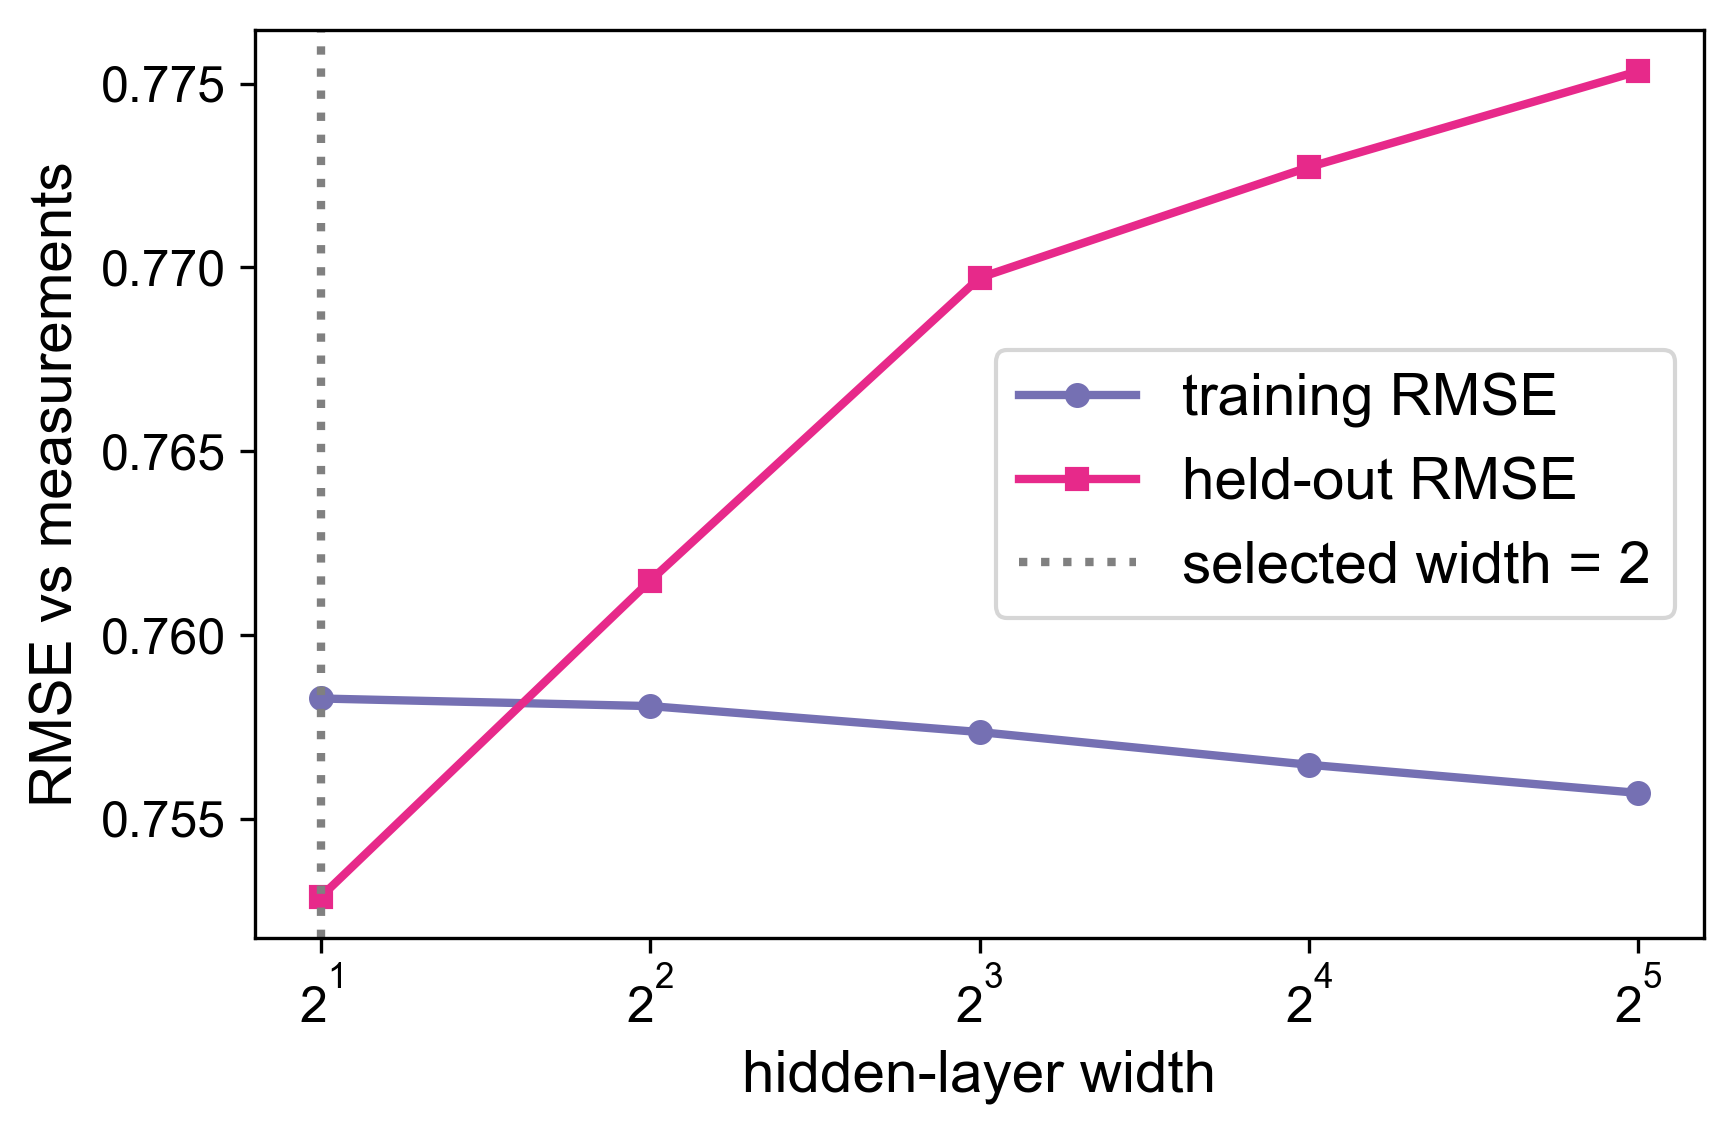

Validation selects width = 2


In [7]:
best_width = WIDTHS[int(np.argmin(val_errors))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(WIDTHS, train_errors, 'o-', color='C2', label='training RMSE')
ax.plot(WIDTHS, val_errors,   's-', color='C3', label='held-out RMSE')
ax.axvline(best_width, color='gray', ls=':', label=f'selected width = {best_width}')
ax.set_xlabel('hidden-layer width'); ax.set_ylabel('RMSE vs measurements')
ax.set_xscale('log', base=2); ax.legend()
plt.tight_layout(); plt.show()

print(f'Validation selects width = {best_width}')

## A check against the known kinetics

Validation chose the network purely from held-out data. Because this is a synthetic study we can also compare each network's recovered growth rate against the true Monod law.

width  2:  mu MAE vs true Monod = 0.0128
width  4:  mu MAE vs true Monod = 0.0192
width  8:  mu MAE vs true Monod = 0.0229
width 16:  mu MAE vs true Monod = 0.0244
width 32:  mu MAE vs true Monod = 0.0247


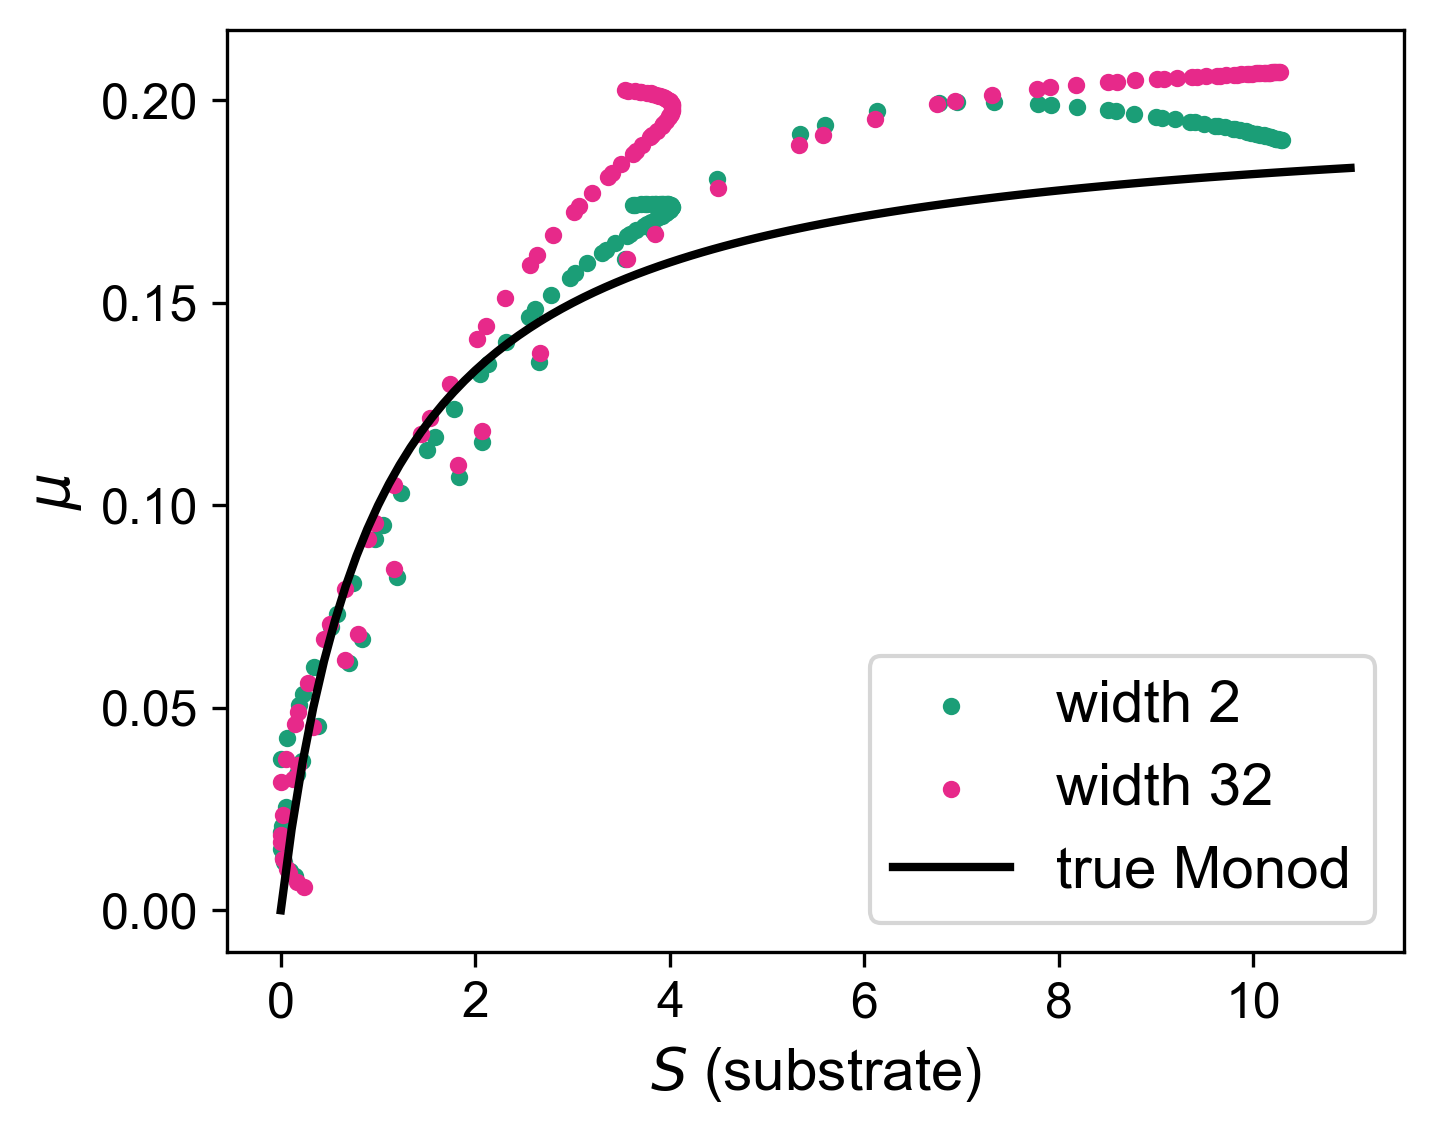

In [8]:
def mu_mae(trained_data):
    S  = np.concatenate([trained_data[k].nn_input[:, 2] for k in range(len(TRAIN_BATCHES))])
    mu = np.concatenate([trained_data[k].nn_output[:, 0] for k in range(len(TRAIN_BATCHES))])
    true_mu = FB_PARAMS['mu_max'] * S / (FB_PARAMS['Ks'] + S)
    return float(np.mean(np.abs(mu - true_mu)))

for width in WIDTHS:
    print(f'width {width:2d}:  mu MAE vs true Monod = {mu_mae(trained_runs[width]):.4f}')

## Learned mu for the selected vs the largest network ##
S_grid = np.linspace(0, 11, 100)
fig, ax = plt.subplots(figsize=(5, 4))
for width, color in [(best_width, 'C0'), (WIDTHS[-1], 'C3')]:
    td = trained_runs[width]
    S  = np.concatenate([td[k].nn_input[:, 2] for k in range(len(TRAIN_BATCHES))])
    mu = np.concatenate([td[k].nn_output[:, 0] for k in range(len(TRAIN_BATCHES))])
    ax.scatter(S, mu, s=10, color=color, label=f'width {width}')
ax.plot(S_grid, FB_PARAMS['mu_max'] * S_grid / (FB_PARAMS['Ks'] + S_grid), 'k-', label='true Monod')
ax.set_xlabel('$S$ (substrate)'); ax.set_ylabel(r'$\mu$'); ax.legend()
plt.tight_layout(); plt.show()

## Summary

- A held-out batch gives an honest measure of generalisation: split the logged runs, train on some, and predict the rest with `model.predict()`.
- Training error alone is misleading here. It sits at the noise floor for every network size, while held-out error reveals that larger networks overfit.
- Selecting the network by held-out RMSE also yields the best recovery of the underlying kinetics, even though the selection used no knowledge of the truth.